
# EDA по датасету GNΩSIS для ПЛИС (FPGA)

**Цель.** Понять структуру датасета, качество данных, распределения ключевых метрик производительности и использования ресурсов ПЛИС, выявить выбросы/аномалии и сформулировать выводы для дальнейшей работы (очистка, моделирование, новые эксперименты).

**Источник данных.** Публичный CSV из набора *GNWSIS* (HuggingFace). Данные представляют собой результаты синтеза и измерений производительности программ под ПЛИС при различных конфигурациях оптимизаций.
Датасет GNΩSIS представляет собой коллекцию результатов синтеза и компиляции приложений под программируемые логические интегральные схемы (ПЛИС, FPGA).
Он был создан для исследований в области High-Level Synthesis (HLS) — технологии, которая позволяет преобразовывать высокоуровневый код (например, на C/C++) в аппаратное описание для FPGA.
Каждая строка датасета соответствует одной конфигурации синтеза:
- фиксированное приложение (например, фильтр, алгоритм линейной алгебры, компьютерное зрение), 
- набор директив компиляции (pipeline, unroll, block access),
- устройство FPGA, на которое выполнялся синтез.

Результат — метрики производительности и использования ресурсов.



## 1. Загрузка данных и описание признаков

Ниже приводится **описание колонок** :
- **Application_Name** *(имя приложения/бенчмарка)* — какой алгоритм синтезировался.
- **Version** *(версия исходного кода/вариант нагрузки)* — номер/файл workload'а.
- **Device** *(модель ПЛИС)* — конкретная целевая микросхема FPGA.
- **Clock_Period_nsec** *(целевой период такта, нс)* — чем меньше, тем выше частота (1/период).
- **Array_1 .. Array_22** *(параметры раскладки массивов/директив)* — схемы доступа к памяти и оптимизации.
- **OuterLoop_1 .. OuterLoop_26** *(директивы верхних циклов)* — например, `pipeline`, `unroll_8`.
- **InnerLoop** (директивы внутренних циклов) — параметры развёртки/конвейера для вложенных циклов.
- **Latency_msec** *(задержка, мс)* — время выполнения аппаратной реализации.
- **Synthesis_Time_sec** *(время синтеза, сек)* — длительность компиляции/синтеза.
- **BRAM_Utilization_percentage** *(% использования встроенной памяти BRAM)* — 0..100.
- **DSP_Utilization_percentage** *(% использования DSP-блоков)* — 0..100.
- **FF_Utilization_percentage** *(% использования триггеров FF)* — 0..100.
- **LUT_Utilization_percentage** *(% использования таблиц истинности LUT)* — 0..100.
- **Speedup** *(ускорение относительно базовой реализации)* — >1 означает ускорение.
- **BRAMs, DSPs, FFs, LUTs** *(абсолютное количество использованных ресурсов)*.

помимо перечисленного, в датасете присутствуют десятки колонок с конфигурациями массивов и циклов — они категориальные и отражают шаблоны оптимизации.


In [1]:

import pandas as pd
import numpy as np
import os
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)

DATA_URL = "https://huggingface.co/datasets/aferikoglou/GNWSIS/resolve/main/GN%CE%A9SIS.csv"

df_raw = pd.read_csv(DATA_URL, encoding="utf-8")
rows, cols = df_raw.shape
print(f"Загружено строк: {rows}, колонок: {cols}")
display(df_raw.head(10))


Загружено строк: 227819, колонок: 93


,Application_Name,Version,Device,Clock_Period_nsec,Array_1,Array_2,Array_3,Array_4,Array_5,Array_6,Array_7,Array_8,Array_9,Array_10,Array_11,Array_12,Array_13,Array_14,Array_15,Array_16,Array_17,Array_18,Array_19,Array_20,Array_21,Array_22,OuterLoop_1,OuterLoop_2,OuterLoop_3,OuterLoop_4,OuterLoop_5,OuterLoop_6,OuterLoop_7,OuterLoop_8,OuterLoop_9,OuterLoop_10,OuterLoop_11,OuterLoop_12,OuterLoop_13,OuterLoop_14,OuterLoop_15,OuterLoop_16,OuterLoop_17,OuterLoop_18,OuterLoop_19,OuterLoop_20,OuterLoop_21,OuterLoop_22,OuterLoop_23,OuterLoop_24,OuterLoop_25,OuterLoop_26,InnerLoop_1_1,InnerLoop_1_2,InnerLoop_1_3,InnerLoop_1_4,InnerLoop_1_5,InnerLoop_1_6,InnerLoop_1_7,InnerLoop_1_8,InnerLoop_1_9,InnerLoop_1_10,InnerLoop_1_11,InnerLoop_1_12,InnerLoop_1_13,InnerLoop_1_14,InnerLoop_1_15,InnerLoop_1_16,InnerLoop_2_1,InnerLoop_2_2,InnerLoop_2_3,InnerLoop_2_4,InnerLoop_2_5,InnerLoop_2_6,InnerLoop_2_7,InnerLoop_3_1,InnerLoop_3_2,InnerLoop_3_3,InnerLoop_3_4,InnerLoop_3_5,InnerLoop_4_1,InnerLoop_4_2,Latency_msec,Synthesis_Time_sec,BRAM_Utilization_percentage,DSP_Utilization_percentage,FF_Utilization_percentage,LUT_Utilization_percentage,Speedup,BRAMs,DSPs,FFs,LUTs
0,rodinia_lc_gicov_0_baseline_0,workload_0.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_2_2,block_8_2,block_4_1,cyclic_8_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,unroll_4,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,101,101,101,101,NaN,NaN,NaN,NaN,NaN
1,rodinia_lc_gicov_0_baseline_0,workload_1.cpp,xczu7ev-ffvc1156-2-e,10.0,block_4_2,cyclic_4_2,block_4_1,block_4_1,block_8_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,pipeline_1,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,101,101,101,101,NaN,NaN,NaN,NaN,NaN
2,rodinia_lc_gicov_0_baseline_0,workload_2.cpp,xczu7ev-ffvc1156-2-e,10.0,block_2_2,block_8_2,block_2_1,cyclic_2_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_64,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,unroll_8,unroll_2,NDIR,NDIR,NDIR,NDIR,0.00000,18,101,101,101,101,NaN,NaN,NaN,NaN,NaN
3,rodinia_lc_gicov_0_baseline_0,workload_3.cpp,xczu7ev-ffvc1156-2-e,10.0,complete_2,complete_2,cyclic_8_1,cyclic_4_1,block_4_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,unroll_2,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,16,101,101,101,101,NaN,NaN,NaN,NaN,NaN
4,rodinia_lc_gicov_0_baseline_0,workload_4.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_4_2,block_2_2,cyclic_8_1,cyclic_8_1,cyclic_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_4,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,pipeline,unroll_8,NDIR,NDIR,NDIR,NDIR,0.00000,18,101,101,101,101,NaN,NaN,NaN,NaN,NaN
5,rodinia_lc_gicov_0_b


## 2. Приведение типов

- Категориальные: названия, версии, устройство, директивы циклов/массивов.
- Числовые: все метрики времени/ускорения/ресурсов.


In [2]:

df = df_raw.copy()

# Явные числовые признаки
num_candidates = [
    "Clock_Period_nsec","Latency_msec","Synthesis_Time_sec",
    "BRAM_Utilization_percentage","DSP_Utilization_percentage",
    "FF_Utilization_percentage","LUT_Utilization_percentage",
    "Speedup","BRAMs","DSPs","FFs","LUTs"
]

for c in num_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Явные категориальные
cat_candidates = ["Application_Name","Version","Device"]
cat_candidates += [c for c in df.columns if c.startswith("Array_")]
cat_candidates += [c for c in df.columns if c.startswith("OuterLoop_")]
cat_candidates += [c for c in df.columns if c.startswith("InnerLoop_")]

for c in cat_candidates:
    if c in df.columns:
        df[c] = df[c].astype("category")

(df.shape, df[["Application_Name","Version","Device","Clock_Period_nsec"]].dtypes)


((227819, 93),
 Application_Name     category
 Version              category
 Device               category
 Clock_Period_nsec     float64
 dtype: object)


## 3. Качество данных

Проверим полноту (пропуски), дубликаты и базовую валидность (проценты в [0, 100], неотрицательный `Speedup`). 


In [3]:

# Пропуски
na_count = df.isna().sum().sort_values(ascending=False)
na_pct = (df.isna().mean()*100).sort_values(ascending=False)

print("Топ по количеству пропусков:")
display(na_count.head(15))

print("\nДоля пропусков (%):")
display(na_pct.head(15))

# Дубликаты
dups = df.duplicated().sum()
print(f"Дубликатов строк: {dups}")

# Валидность диапазонов
validity = {}
for c in ["BRAM_Utilization_percentage","DSP_Utilization_percentage","FF_Utilization_percentage","LUT_Utilization_percentage"]:
    if c in df.columns:
        s = df[c].dropna()
        validity[f"{c} in [0,100]"] = bool(((s>=0)&(s<=100)).mean() > 0.99)
if "Speedup" in df.columns:
    s = df["Speedup"].dropna()
    validity["Speedup >= 0"] = bool((s>=0).mean() > 0.99)
print("\nВалидность правил (порог 99% корректных):")
print(validity)


Топ по количеству пропусков:


Speedup              48019
LUTs                 40465
BRAMs                39711
FFs                  38714
DSPs                 38411
Array_2                  0
Array_3                  0
Array_4                  0
Application_Name         0
Version                  0
Device                   0
Clock_Period_nsec        0
Array_1                  0
Array_10                 0
Array_11                 0
dtype: int64


Доля пропусков (%):


Speedup              21.077698
LUTs                 17.761907
BRAMs                17.430943
FFs                  16.993315
DSPs                 16.860315
Array_2               0.000000
Array_3               0.000000
Array_4               0.000000
Application_Name      0.000000
Version               0.000000
Device                0.000000
Clock_Period_nsec     0.000000
Array_1               0.000000
Array_10              0.000000
Array_11              0.000000
dtype: float64

Дубликатов строк: 0

Валидность правил (порог 99% корректных):
{'BRAM_Utilization_percentage in [0,100]': False, 'DSP_Utilization_percentage in [0,100]': False, 'FF_Utilization_percentage in [0,100]': False, 'LUT_Utilization_percentage in [0,100]': False, 'Speedup >= 0': True}



## 4. Структура и базовые статистики

Посмотрим первые строки и описательную статистику по числовым метрикам.


In [4]:

display(df.head(10))
desc = df.select_dtypes(include=[np.number]).describe().T
display(desc)


,Application_Name,Version,Device,Clock_Period_nsec,Array_1,Array_2,Array_3,Array_4,Array_5,Array_6,Array_7,Array_8,Array_9,Array_10,Array_11,Array_12,Array_13,Array_14,Array_15,Array_16,Array_17,Array_18,Array_19,Array_20,Array_21,Array_22,OuterLoop_1,OuterLoop_2,OuterLoop_3,OuterLoop_4,OuterLoop_5,OuterLoop_6,OuterLoop_7,OuterLoop_8,OuterLoop_9,OuterLoop_10,OuterLoop_11,OuterLoop_12,OuterLoop_13,OuterLoop_14,OuterLoop_15,OuterLoop_16,OuterLoop_17,OuterLoop_18,OuterLoop_19,OuterLoop_20,OuterLoop_21,OuterLoop_22,OuterLoop_23,OuterLoop_24,OuterLoop_25,OuterLoop_26,InnerLoop_1_1,InnerLoop_1_2,InnerLoop_1_3,InnerLoop_1_4,InnerLoop_1_5,InnerLoop_1_6,InnerLoop_1_7,InnerLoop_1_8,InnerLoop_1_9,InnerLoop_1_10,InnerLoop_1_11,InnerLoop_1_12,InnerLoop_1_13,InnerLoop_1_14,InnerLoop_1_15,InnerLoop_1_16,InnerLoop_2_1,InnerLoop_2_2,InnerLoop_2_3,InnerLoop_2_4,InnerLoop_2_5,InnerLoop_2_6,InnerLoop_2_7,InnerLoop_3_1,InnerLoop_3_2,InnerLoop_3_3,InnerLoop_3_4,InnerLoop_3_5,InnerLoop_4_1,InnerLoop_4_2,Latency_msec,Synthesis_Time_sec,BRAM_Utilization_percentage,DSP_Utilization_percentage,FF_Utilization_percentage,LUT_Utilization_percentage,Speedup,BRAMs,DSPs,FFs,LUTs
0,rodinia_lc_gicov_0_baseline_0,workload_0.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_2_2,block_8_2,block_4_1,cyclic_8_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,unroll_4,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,101,101,101,101,NaN,NaN,NaN,NaN,NaN
1,rodinia_lc_gicov_0_baseline_0,workload_1.cpp,xczu7ev-ffvc1156-2-e,10.0,block_4_2,cyclic_4_2,block_4_1,block_4_1,block_8_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,pipeline_1,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,101,101,101,101,NaN,NaN,NaN,NaN,NaN
2,rodinia_lc_gicov_0_baseline_0,workload_2.cpp,xczu7ev-ffvc1156-2-e,10.0,block_2_2,block_8_2,block_2_1,cyclic_2_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_64,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,unroll_8,unroll_2,NDIR,NDIR,NDIR,NDIR,0.00000,18,101,101,101,101,NaN,NaN,NaN,NaN,NaN
3,rodinia_lc_gicov_0_baseline_0,workload_3.cpp,xczu7ev-ffvc1156-2-e,10.0,complete_2,complete_2,cyclic_8_1,cyclic_4_1,block_4_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,unroll_2,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,16,101,101,101,101,NaN,NaN,NaN,NaN,NaN
4,rodinia_lc_gicov_0_baseline_0,workload_4.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_4_2,block_2_2,cyclic_8_1,cyclic_8_1,cyclic_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_4,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,pipeline,unroll_8,NDIR,NDIR,NDIR,NDIR,0.00000,18,101,101,101,101,NaN,NaN,NaN,NaN,NaN
5,rodinia_lc_gicov_0_b

,count,mean,std,min,25%,50%,75%,max
Clock_Period_nsec,227819.0,6.057069,2.832689,3.330000,3.330000,5.000000,10.000000,1.000000e+01
Latency_msec,227819.0,25165.206053,154953.843817,0.000000,0.072447,4.965240,56.564060,1.000000e+06
Synthesis_Time_sec,227819.0,748.425303,1088.406141,2.000000,97.000000,234.000000,850.000000,1.080200e+04
BRAM_Utilization_percentage,227819.0,29.075911,44.493758,1.000000,1.000000,3.000000,47.000000,1.314000e+03
DSP_Utilization_percentage,227819.0,20.638178,39.150321,1.000000,1.000000,1.000000,8.000000,8.290000e+02
FF_Utilization_percentage,227819.0,23.405594,38.705011,1.000000,1.000000,4.000000,21.000000,8.480000e+02
LUT_Utilization_percentage,227819.0,32.205755,60.717239,1.000000,3.000000,11.000000,46.000000,4.601000e+03
Speedup,179800.0,81.297745,1402.312918,0.000021,1.667913,4.227364,17.243978,5.410318e+04
BRAMs,188108.0,108.058589,139.652033,6.000000,43.000000,43.000000,129.000000,1.036000e+03
DSPs,189408.0,128.871521,285.640235,17.000000,17.000000,68.000000,68.000000,5.335000e+03



## 5. Распределения ключевых метрик

Ниже — по набору графиков на метрику: гистограмма (обычная) и boxplot.  
Для скошенных распределений строим дополнительно гистограмму с лог-шкалой по оси X.


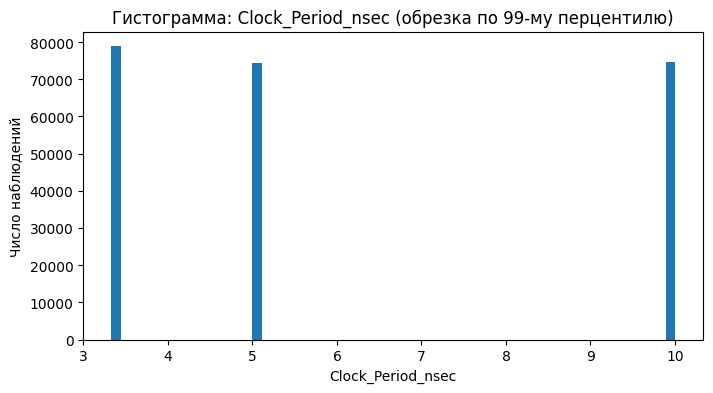

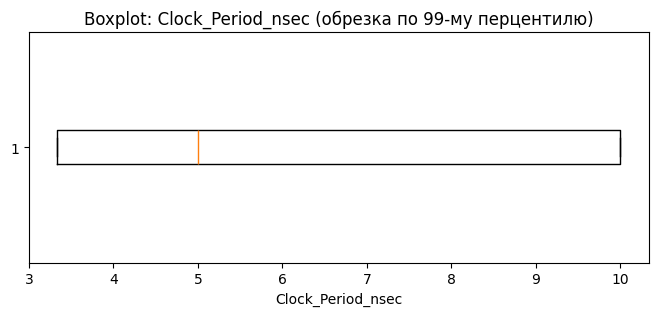

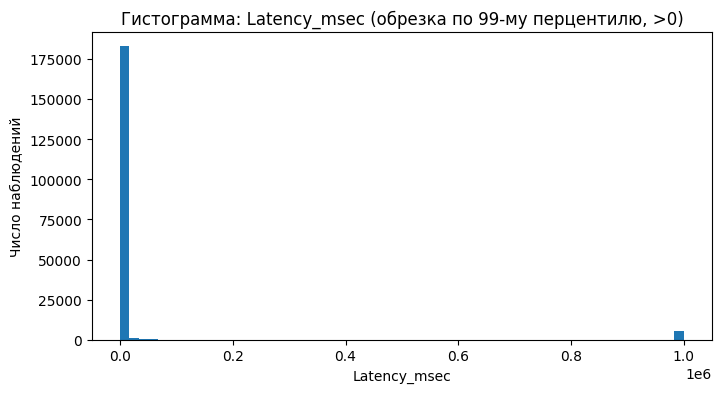

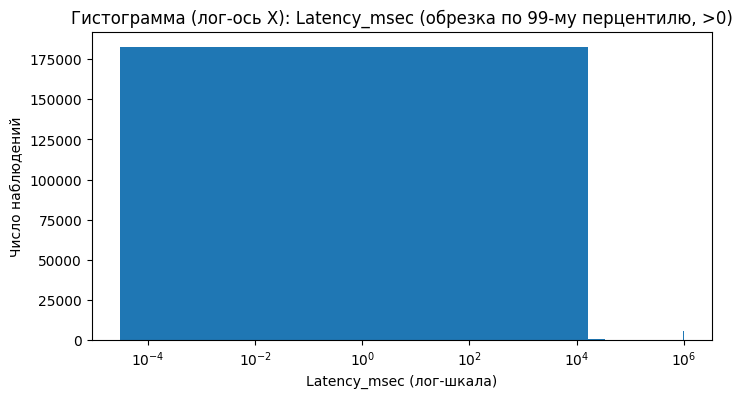

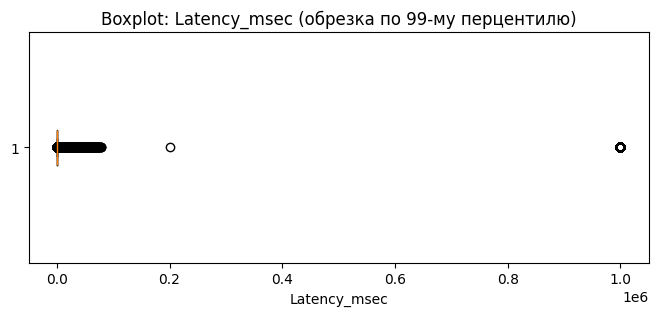

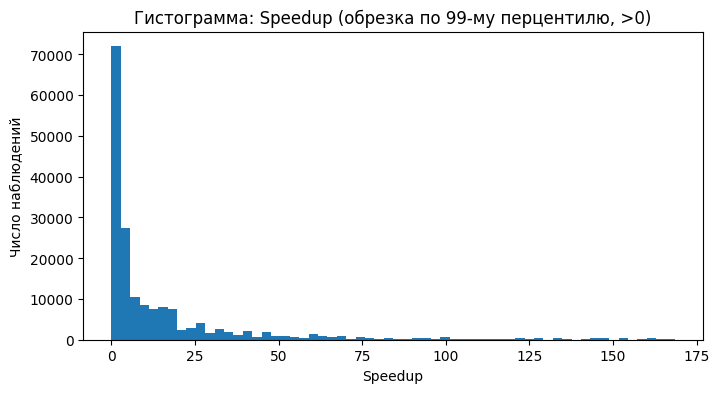

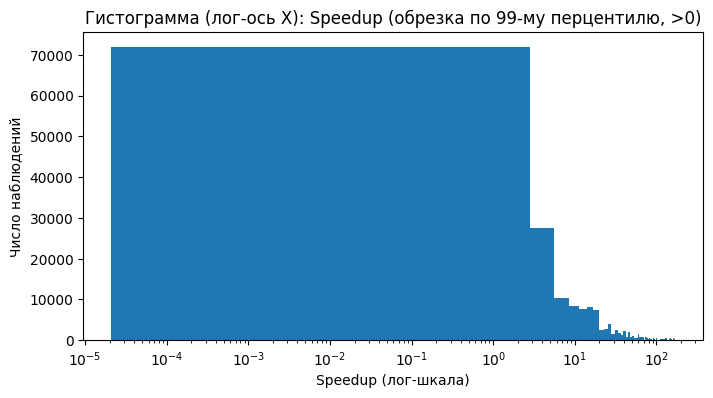

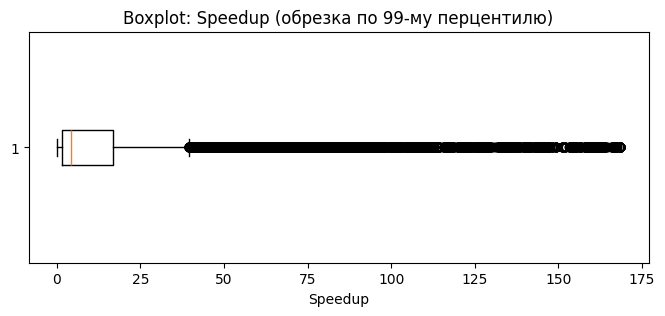

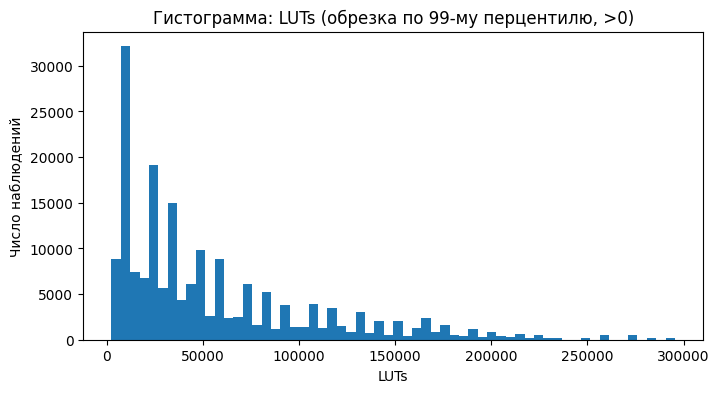

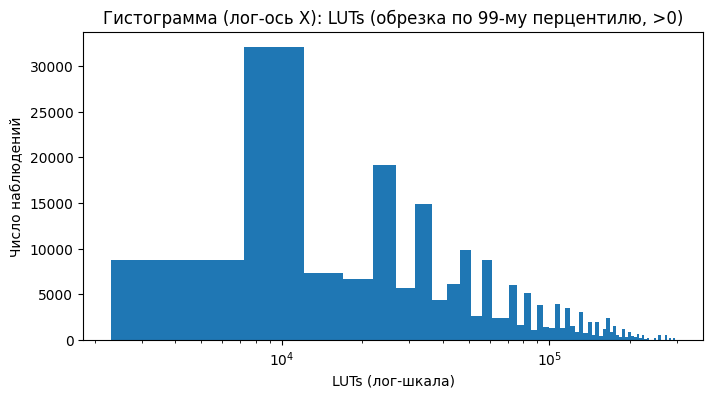

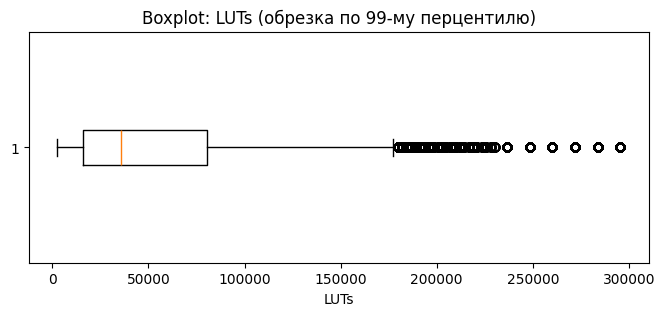

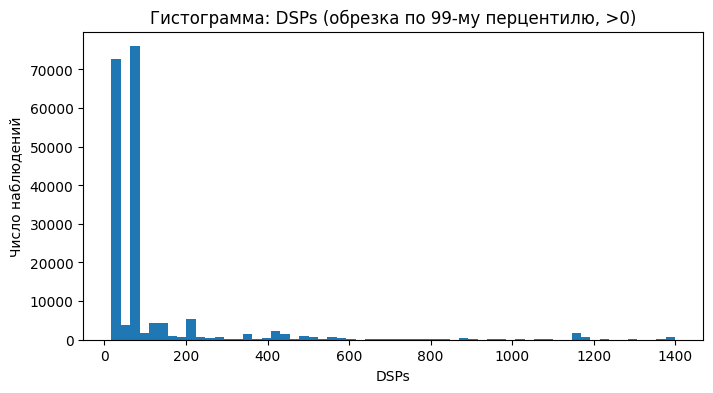

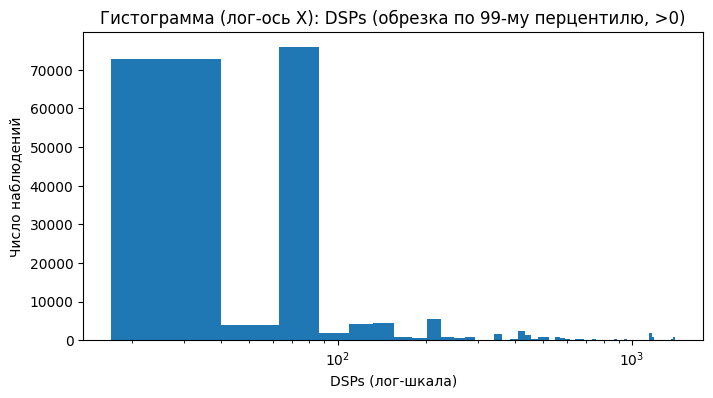

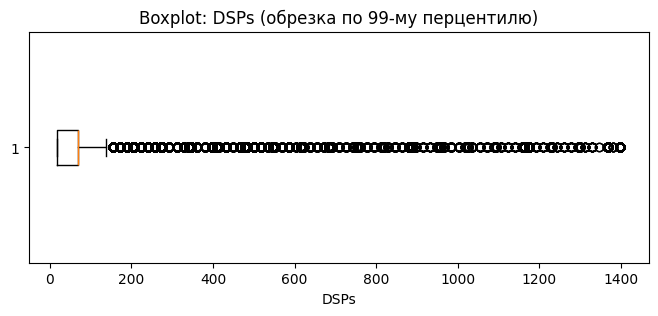

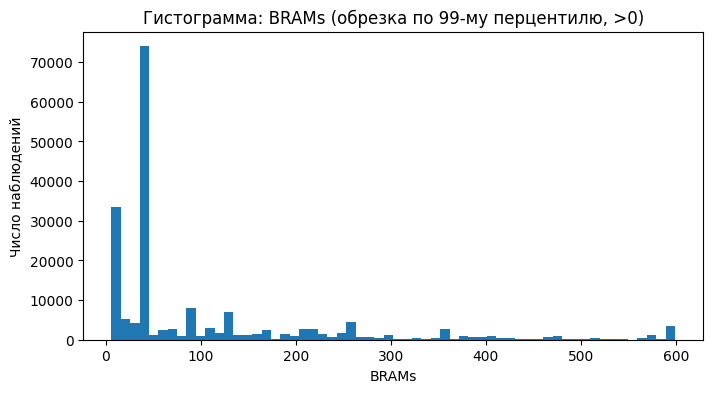

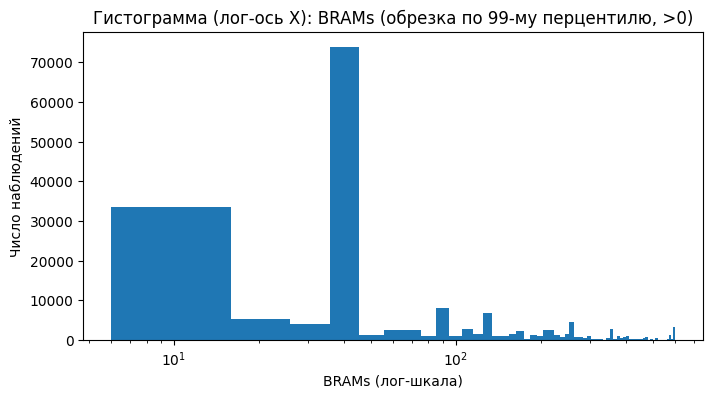

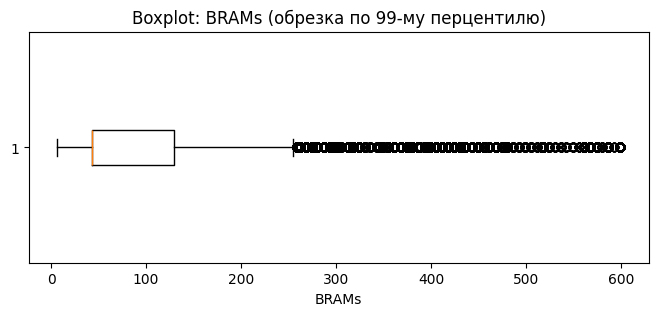

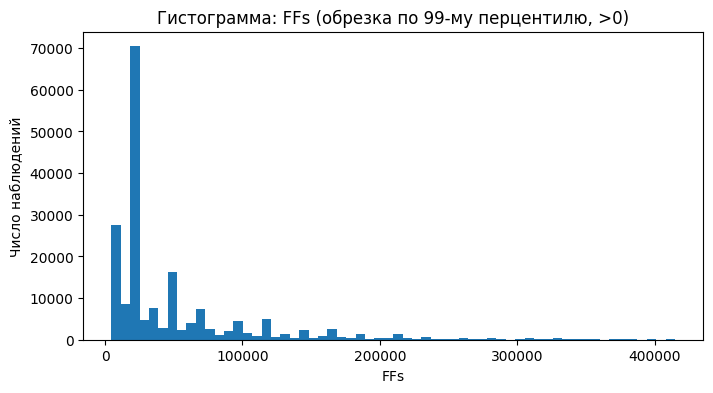

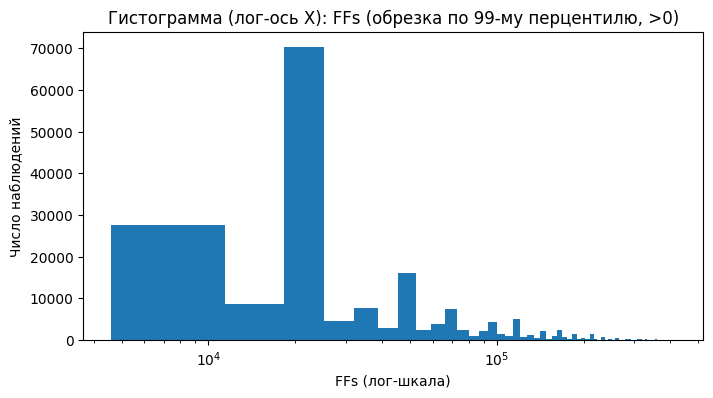

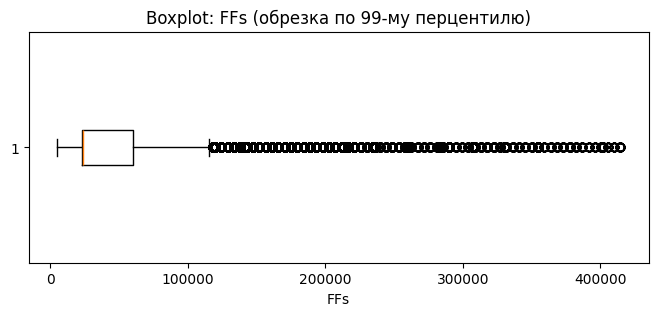

In [5]:

def hist_box(series, name, bins=60, logx=False, clip_pct=0.99):
    s = series.dropna()
    if s.empty: 
        print(f"{name}: данных нет")
        return
    hi = s.quantile(clip_pct)
    s = s[s <= hi]
    if logx:
        s = s[s > 0]
    # hist
    plt.figure(figsize=(8,4))
    plt.hist(s, bins=bins)
    plt.xlabel(name)
    plt.ylabel("Число наблюдений")
    plt.title(f"Гистограмма: {name} (обрезка по {int(clip_pct*100)}-му перцентилю" + (", >0" if logx else "") + ")")
    plt.show()
    # optional log-x hist
    if logx:
        plt.figure(figsize=(8,4))
        plt.hist(s, bins=bins)
        plt.xscale("log")
        plt.xlabel(f"{name} (лог-шкала)")
        plt.ylabel("Число наблюдений")
        plt.title(f"Гистограмма (лог-ось X): {name} (обрезка по {int(clip_pct*100)}-му перцентилю, >0)")
        plt.show()
    # boxplot
    plt.figure(figsize=(8,3))
    plt.boxplot(s.values, vert=False)
    plt.xlabel(name)
    plt.title(f"Boxplot: {name} (обрезка по {int(clip_pct*100)}-му перцентилю)")
    plt.show()

for col, logx in [
    ("Clock_Period_nsec", False),
    ("Latency_msec", True),
    ("Speedup", True),
    ("LUTs", True),
    ("DSPs", True),
    ("BRAMs", True),
    ("FFs", True),
]:
    if col in df.columns:
        hist_box(df[col], col, logx=logx)



**Интерпретация графиков (кратко):**
- `Clock_Period_nsec` — дискретные кластеры (обычно 3/5/10 нс): эксперименты проводились на фиксированных целевых частотах.
- `Latency_msec` — длинный правый хвост, встречаются экстремальные задержки, следовательно возможные неудачные конфигурации/ошибки.
- `Speedup` — большинство реализаций дают умеренное ускорение, но есть редкие высокие значения (интересны для оптимизаций).
- `LUTs/DSPs/BRAMs/FFs` — потребление ресурсов имеет длинный хвост, т.е. встречаются как компактные, так и очень «дорогие» реализации.



## 6. Выбросы и аномалии

Оценим выбросы двумя подходами:
- **IQR**: границы `Q1 − 1.5⋅IQR` и `Q3 + 1.5⋅IQR`.
- **Устойчивый Z-score** по медиане и MAD (более устойчив к хвостам).


In [6]:

num_df = df.select_dtypes(include=[np.number]).copy()

def iqr_report(s: pd.Series):
    s = s.dropna()
    if s.empty: 
        return None
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    mask = (s < lo) | (s > hi)
    return {"lower": float(lo), "upper": float(hi), "outliers": int(mask.sum()), "outlier_ratio": float(mask.mean())}

iqr_rows = []
for c in num_df.columns:
    rep = iqr_report(num_df[c])
    if rep is not None:
        rep.update({"column": c})
        iqr_rows.append(rep)

iqr_df = pd.DataFrame(iqr_rows).sort_values("outlier_ratio", ascending=False)
display(iqr_df.head(12))

# Z-score 
def robust_z(x):
    x = x.astype(float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if mad == 0:
        return np.zeros_like(x, dtype=float)
    return 0.6745*(x - med)/mad

z_rows = []
for c in num_df.columns:
    z = robust_z(num_df[c].values)
    ratio = np.nanmean(np.abs(z) > 3)
    z_rows.append({"column": c, "z_outlier_ratio": float(ratio)})
z_df = pd.DataFrame(z_rows).sort_values("z_outlier_ratio", ascending=False)
display(z_df.head(12))


,lower,upper,outliers,outlier_ratio,column
4,-9.500000,18.500000,48052,0.210922,DSP_Utilization_percentage
5,-29.000000,51.000000,41200,0.180845,FF_Utilization_percentage
1,-84.664971,141.301479,40218,0.176535,Latency_msec
9,-59.500000,144.500000,27019,0.142650,DSPs
10,-32256.000000,115200.000000,24086,0.127368,FFs
8,-86.000000,258.000000,23430,0.124556,BRAMs
7,-21.696184,40.608076,21112,0.117419,Speedup
2,-1032.500000,1979.500000,25658,0.112624,Synthesis_Time_sec
11,-83814.000000,182698.000000,8747,0.046687,LUTs
6,-61.500000,110.500000,2049,0.008994,LUT_Utilization_percentage


,column,z_outlier_ratio
3,BRAM_Utilization_percentage,0.381105
1,Latency_msec,0.328954
5,FF_Utilization_percentage,0.265996
6,LUT_Utilization_percentage,0.236464
2,Synthesis_Time_sec,0.224318
7,Speedup,0.163564
8,BRAMs,0.162102
10,FFs,0.145335
11,LUTs,0.087886
9,DSPs,0.076868



**Вывод по аномалиям.** Наибольшая доля выбросов обычно наблюдается у `Latency_msec`, `DSPs`, `FFs` и `LUTs`.  
Это соответствует ожиданиям: часть конфигураций может приводить к чрезмерной задержке или ресурсоёмкости. Такие точки стоит либо фильтровать, либо разбирать отдельно.



## 7. Корреляции и согласованность

Посмотрим линейные (Пирсон) и ранговые (Спирмен) корреляции между числовыми колонками и выделим связь с `Speedup`.


In [7]:

corr_p = df.corr(numeric_only=True, method="pearson")
corr_s = df.corr(numeric_only=True, method="spearman")

if "Speedup" in corr_p.columns:
    top_p = corr_p["Speedup"].drop("Speedup").abs().sort_values(ascending=False).head(10)
    print("Топ корреляций (Пирсон) с Speedup:")
    display(top_p)
else:
    print("Speedup отсутствует")
if "Version" in df.columns and "Device" in df.columns:
    top_versions = df["Version"].value_counts().head(10).index
    ct = pd.crosstab(df["Device"], df["Version"].where(df["Version"].isin(top_versions)))
    display(ct)


Топ корреляций (Пирсон) с Speedup:


Clock_Period_nsec              0.046917
BRAMs                          0.032733
LUTs                           0.020446
BRAM_Utilization_percentage    0.018543
FFs                            0.013232
DSPs                           0.012093
FF_Utilization_percentage      0.006939
Latency_msec                   0.005946
DSP_Utilization_percentage     0.005482
LUT_Utilization_percentage     0.005421
Name: Speedup, dtype: float64

Version,workload_0.cpp,workload_1.cpp,workload_10.cpp,workload_11.cpp,workload_12.cpp,workload_17.cpp,workload_5.cpp,workload_6.cpp,workload_7.cpp,workload_8.cpp
Device,,,,,,,,,,
xczu7ev-ffvc1156-2-e,44,44,44,44,44,44,44,44,44,44



## 8. Подготовка очищенной версии датасета

- Обрезаем проценты использования в диапазоне [0, 100].  
- Маскируем отрицательные `Speedup` как пропуски.  
- Сохраняем результат в `data/` как CSV и Parquet.


In [8]:
df_clean = df.copy()

for c in ["BRAM_Utilization_percentage", "DSP_Utilization_percentage",
          "FF_Utilization_percentage", "LUT_Utilization_percentage"]:
    if c in df_clean.columns:
        df_clean.loc[df_clean[c] < 0, c] = 0
        df_clean.loc[df_clean[c] > 100, c] = 100

if "Speedup" in df_clean.columns:
    df_clean.loc[df_clean["Speedup"] < 0, "Speedup"] = np.nan

save_dir = "./newdata"
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, "gnwsis_clean.csv")
parquet_path = os.path.join(save_dir, "gnwsis_clean.parquet")

df_clean.to_csv(csv_path, index=False)
try:
    df_clean.to_parquet(parquet_path, index=False)
    print("Сохранено:", csv_path, "и", parquet_path)
except Exception as e:
    print("Сохранён CSV:", csv_path)

display(df_clean.head(10))

Сохранён CSV: ./newdata/gnwsis_clean.csv


,Application_Name,Version,Device,Clock_Period_nsec,Array_1,Array_2,Array_3,Array_4,Array_5,Array_6,Array_7,Array_8,Array_9,Array_10,Array_11,Array_12,Array_13,Array_14,Array_15,Array_16,Array_17,Array_18,Array_19,Array_20,Array_21,Array_22,OuterLoop_1,OuterLoop_2,OuterLoop_3,OuterLoop_4,OuterLoop_5,OuterLoop_6,OuterLoop_7,OuterLoop_8,OuterLoop_9,OuterLoop_10,OuterLoop_11,OuterLoop_12,OuterLoop_13,OuterLoop_14,OuterLoop_15,OuterLoop_16,OuterLoop_17,OuterLoop_18,OuterLoop_19,OuterLoop_20,OuterLoop_21,OuterLoop_22,OuterLoop_23,OuterLoop_24,OuterLoop_25,OuterLoop_26,InnerLoop_1_1,InnerLoop_1_2,InnerLoop_1_3,InnerLoop_1_4,InnerLoop_1_5,InnerLoop_1_6,InnerLoop_1_7,InnerLoop_1_8,InnerLoop_1_9,InnerLoop_1_10,InnerLoop_1_11,InnerLoop_1_12,InnerLoop_1_13,InnerLoop_1_14,InnerLoop_1_15,InnerLoop_1_16,InnerLoop_2_1,InnerLoop_2_2,InnerLoop_2_3,InnerLoop_2_4,InnerLoop_2_5,InnerLoop_2_6,InnerLoop_2_7,InnerLoop_3_1,InnerLoop_3_2,InnerLoop_3_3,InnerLoop_3_4,InnerLoop_3_5,InnerLoop_4_1,InnerLoop_4_2,Latency_msec,Synthesis_Time_sec,BRAM_Utilization_percentage,DSP_Utilization_percentage,FF_Utilization_percentage,LUT_Utilization_percentage,Speedup,BRAMs,DSPs,FFs,LUTs
0,rodinia_lc_gicov_0_baseline_0,workload_0.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_2_2,block_8_2,block_4_1,cyclic_8_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,unroll_4,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,100,100,100,100,NaN,NaN,NaN,NaN,NaN
1,rodinia_lc_gicov_0_baseline_0,workload_1.cpp,xczu7ev-ffvc1156-2-e,10.0,block_4_2,cyclic_4_2,block_4_1,block_4_1,block_8_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,pipeline_1,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,100,100,100,100,NaN,NaN,NaN,NaN,NaN
2,rodinia_lc_gicov_0_baseline_0,workload_2.cpp,xczu7ev-ffvc1156-2-e,10.0,block_2_2,block_8_2,block_2_1,cyclic_2_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_64,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,unroll_8,unroll_2,NDIR,NDIR,NDIR,NDIR,0.00000,18,100,100,100,100,NaN,NaN,NaN,NaN,NaN
3,rodinia_lc_gicov_0_baseline_0,workload_3.cpp,xczu7ev-ffvc1156-2-e,10.0,complete_2,complete_2,cyclic_8_1,cyclic_4_1,block_4_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,unroll_2,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,16,100,100,100,100,NaN,NaN,NaN,NaN,NaN
4,rodinia_lc_gicov_0_baseline_0,workload_4.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_4_2,block_2_2,cyclic_8_1,cyclic_8_1,cyclic_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_4,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,pipeline,unroll_8,NDIR,NDIR,NDIR,NDIR,0.00000,18,100,100,100,100,NaN,NaN,NaN,NaN,NaN
5,rodinia_lc_gicov_0_b


## 9. Итоговые выводы

1. **Качество данных.** Пропуски сконцентрированы в метриках `Speedup`, `LUTs`, `FFs`, `DSPs`, `BRAMs` (до ~20%). Дубликатов нет. Валидация процентов выявляет значения за пределами [0,100] (исправлено в очищенной версии).
2. **Распределения.** `Speedup` и `Latency_msec` имеют длинные хвосты (редкие экстремальные случаи). Ресурсы (`LUTs`, `FFs`, `DSPs`, `BRAMs`) распределены правоскошенно, что типично для ПЛИС.
3. **Выбросы.** Наибольшая доля выбросов у `Latency_msec`, `DSPs`, `FFs`. Это комбинация неудачных конфигураций и особенностей синтеза.
4. **Корреляции.** Связь отдельных ресурсов со `Speedup` слабая, следовательно ускорение определяется комбинациями факторов и архитектурными директивами, а не одним параметром.
5. **Рекомендации.**
   - Для моделирования: использовать очищенную версию.
   - Рассматривать совместно конфигурационные признаки (директивы массивов/циклов) и ресурсы.
   - Отдельно анализировать «супербыстрые» реализации (верхний 1%) — там скрыты лучшие практики.

**Практическая ценность датасета**

Для инженеров FPGA: датасет помогает понять, какие комбинации директив дают лучший баланс между производительностью и затратами ресурсов.

Для исследователей ML: данные используются для обучения моделей, которые автоматически предсказывают результаты синтеза (например, Speedup или Utilization) без необходимости запускать HLS.

Для студентов: это пример реальных данных из области электронного проектирования, где результаты измерений содержат шум, пропуски и выбросы.


## Визуализации (Seaborn) и дополнительные проверки

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.1)

**Распределение тактового периода (нс)** — кластерность по фиксированным целевым частотам.

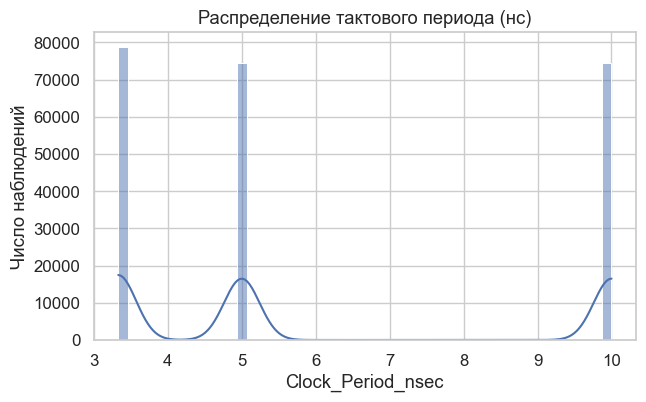

In [10]:
if "Clock_Period_nsec" in df_clean.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df_clean["Clock_Period_nsec"].dropna(), bins=50, kde=True)
    plt.title("Распределение тактового периода (нс)")
    plt.xlabel("Clock_Period_nsec")
    plt.ylabel("Число наблюдений")
    plt.show()


**Задержка (мс)** — длинный правый хвост; boxplot показывает выбросы.

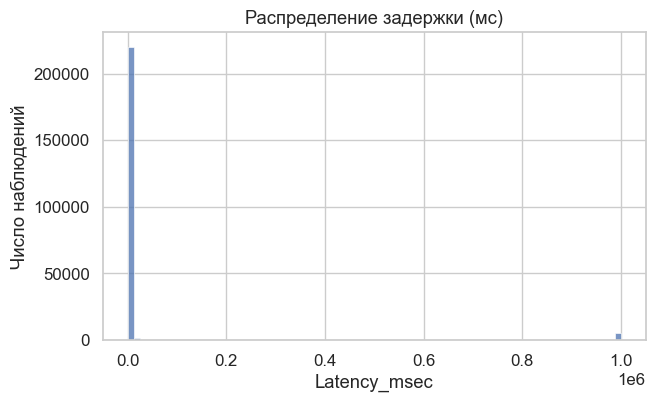

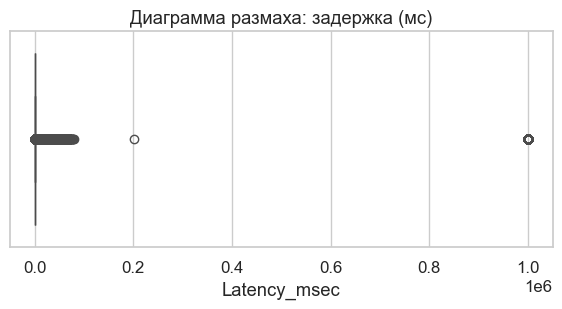

In [11]:
if "Latency_msec" in df.columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df["Latency_msec"].dropna(), bins=80)
    plt.title("Распределение задержки (мс)")
    plt.xlabel("Latency_msec"); plt.ylabel("Число наблюдений")
    plt.show()

    plt.figure(figsize=(7,2.8))
    sns.boxplot(x=df["Latency_msec"])
    plt.title("Диаграмма размаха: задержка (мс)")
    plt.xlabel("Latency_msec")
    plt.show()

**Speedup** — скошенное распределение; лог-шкала позволяет увидеть хвост.

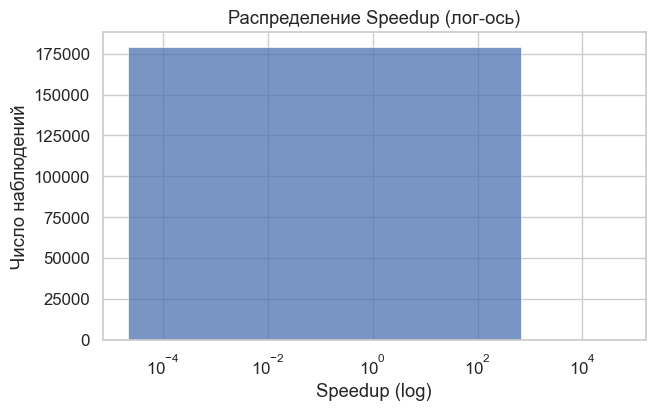

In [12]:
if "Speedup" in df.columns:
    s = df.loc[df["Speedup"]>0, "Speedup"].dropna()
    if not s.empty:
        plt.figure(figsize=(7,4))
        sns.histplot(s, bins=80)
        plt.xscale("log")
        plt.title("Распределение Speedup (лог-ось)")
        plt.xlabel("Speedup (log)"); plt.ylabel("Число наблюдений")
        plt.show()

**Связь Speedup и LUTs** — разброс, линейной зависимости почти нет.

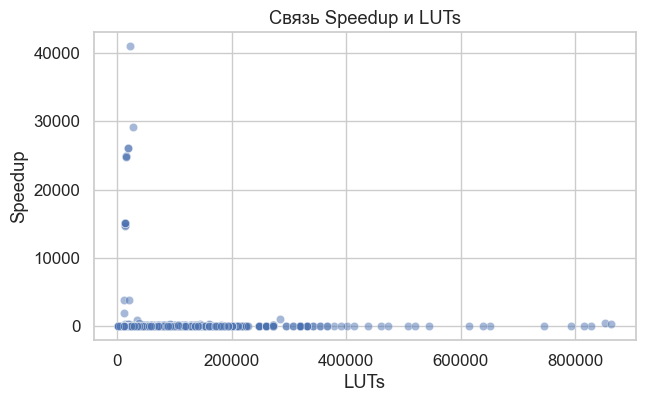

In [13]:
if set(["LUTs","Speedup"]).issubset(df.columns):
    sample = df.sample(min(len(df), 5000), random_state=42)
    plt.figure(figsize=(7,4))
    sns.scatterplot(data=sample, x="LUTs", y="Speedup", alpha=0.5)
    plt.title("Связь Speedup и LUTs")
    plt.xlabel("LUTs"); plt.ylabel("Speedup")
    plt.show()

**Корреляции (Spearman)** — слабые связи с Speedup; важна комбинация факторов.

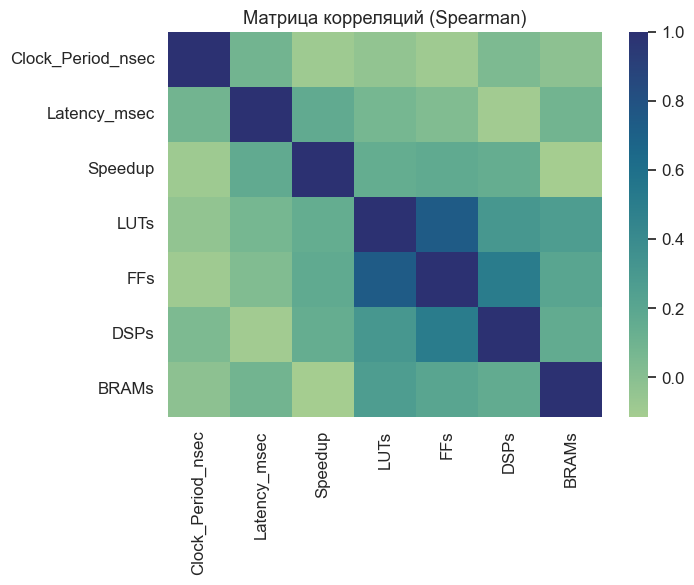

In [14]:
num_cols = [c for c in ["Clock_Period_nsec","Latency_msec","Speedup","LUTs","FFs","DSPs","BRAMs"] if c in df.columns]
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True, method="spearman")
    plt.figure(figsize=(7,5))
    sns.heatmap(corr, annot=False, cmap="crest")
    plt.title("Матрица корреляций (Spearman)")
    plt.show()

**Сохранение очищенной версии** в локальную папку `newdata/` для повторного использования.

In [15]:
import os
import numpy as np

df_clean = df.copy()
for c in ["BRAM_Utilization_percentage","DSP_Utilization_percentage","FF_Utilization_percentage","LUT_Utilization_percentage"]:
    if c in df_clean.columns:
        df_clean.loc[df_clean[c] < 0, c] = 0
        df_clean.loc[df_clean[c] > 100, c] = 100
if "Speedup" in df_clean.columns:
    df_clean.loc[df_clean["Speedup"] < 0, "Speedup"] = np.nan

save_dir = "./newdata"
os.makedirs(save_dir, exist_ok=True)
csv_path = os.path.join(save_dir, "gnwsis_clean.csv")
df_clean.to_csv(csv_path, index=False)
df_clean.head(10)

,Application_Name,Version,Device,Clock_Period_nsec,Array_1,Array_2,Array_3,Array_4,Array_5,Array_6,Array_7,Array_8,Array_9,Array_10,Array_11,Array_12,Array_13,Array_14,Array_15,Array_16,Array_17,Array_18,Array_19,Array_20,Array_21,Array_22,OuterLoop_1,OuterLoop_2,OuterLoop_3,OuterLoop_4,OuterLoop_5,OuterLoop_6,OuterLoop_7,OuterLoop_8,OuterLoop_9,OuterLoop_10,OuterLoop_11,OuterLoop_12,OuterLoop_13,OuterLoop_14,OuterLoop_15,OuterLoop_16,OuterLoop_17,OuterLoop_18,OuterLoop_19,OuterLoop_20,OuterLoop_21,OuterLoop_22,OuterLoop_23,OuterLoop_24,OuterLoop_25,OuterLoop_26,InnerLoop_1_1,InnerLoop_1_2,InnerLoop_1_3,InnerLoop_1_4,InnerLoop_1_5,InnerLoop_1_6,InnerLoop_1_7,InnerLoop_1_8,InnerLoop_1_9,InnerLoop_1_10,InnerLoop_1_11,InnerLoop_1_12,InnerLoop_1_13,InnerLoop_1_14,InnerLoop_1_15,InnerLoop_1_16,InnerLoop_2_1,InnerLoop_2_2,InnerLoop_2_3,InnerLoop_2_4,InnerLoop_2_5,InnerLoop_2_6,InnerLoop_2_7,InnerLoop_3_1,InnerLoop_3_2,InnerLoop_3_3,InnerLoop_3_4,InnerLoop_3_5,InnerLoop_4_1,InnerLoop_4_2,Latency_msec,Synthesis_Time_sec,BRAM_Utilization_percentage,DSP_Utilization_percentage,FF_Utilization_percentage,LUT_Utilization_percentage,Speedup,BRAMs,DSPs,FFs,LUTs
0,rodinia_lc_gicov_0_baseline_0,workload_0.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_2_2,block_8_2,block_4_1,cyclic_8_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,unroll_4,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,100,100,100,100,NaN,NaN,NaN,NaN,NaN
1,rodinia_lc_gicov_0_baseline_0,workload_1.cpp,xczu7ev-ffvc1156-2-e,10.0,block_4_2,cyclic_4_2,block_4_1,block_4_1,block_8_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_2,pipeline_1,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,17,100,100,100,100,NaN,NaN,NaN,NaN,NaN
2,rodinia_lc_gicov_0_baseline_0,workload_2.cpp,xczu7ev-ffvc1156-2-e,10.0,block_2_2,block_8_2,block_2_1,cyclic_2_1,block_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_64,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,unroll_8,unroll_2,NDIR,NDIR,NDIR,NDIR,0.00000,18,100,100,100,100,NaN,NaN,NaN,NaN,NaN
3,rodinia_lc_gicov_0_baseline_0,workload_3.cpp,xczu7ev-ffvc1156-2-e,10.0,complete_2,complete_2,cyclic_8_1,cyclic_4_1,block_4_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_8,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline_1,unroll_2,pipeline,NDIR,NDIR,NDIR,NDIR,0.00000,16,100,100,100,100,NaN,NaN,NaN,NaN,NaN
4,rodinia_lc_gicov_0_baseline_0,workload_4.cpp,xczu7ev-ffvc1156-2-e,10.0,cyclic_4_2,block_2_2,cyclic_8_1,cyclic_8_1,cyclic_2_1,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll_4,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,pipeline,NDIR,NDIR,NDIR,NDIR,NDIR,NDIR,unroll,pipeline,unroll_8,NDIR,NDIR,NDIR,NDIR,0.00000,18,100,100,100,100,NaN,NaN,NaN,NaN,NaN
5,rodinia_lc_gicov_0_b

### Заключение
1) Качество данных: пропуски сконцентрированы в метриках Speedup и ресурсов; дубликатов нет; проценты местами выходили за [0,100] и приведены к допустимому диапазону.  
2) Распределения: Speedup и Latency имеют длинные хвосты; ресурсы правоскошенны.  
3) Выбросы: существенны по Latency и ресурсам, требуют фильтрации/робастных методов.  
4) Корреляции: связи со Speedup слабые по отдельным признакам; важны комбинации директив и ресурсов.  
5) Практика: использовать очищенную версию, лог-преобразования для хвостов, анализировать «супербыстрые» конфигурации отдельно.